        curvatures_sub = (labels_sub, curv_in_sub, curv_rec_sub, curv_lat_sub, curv_lat_norm_sub, curv_true,
                      curv_learned, curv_learned_rotated, z_grid)
        curvatures_emp_full = (labels, curv_in, curv_lat, curv_lat_norm, curv_rec)
        points_sub = (inputs_sub, latents_sub, recons_sub)
        points = (inputs, latents, recons)

In [30]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


def plot_inputs_latents(base_path_curv, file_paths, save_path,
                        dataset_name="s2_synthetic", no_axis=False, plot_recons=False, show_plot=False, torus_normalized=False):
    os.makedirs(save_path, exist_ok=True)
    def _scatter_datapoints(ax, data, colors=None, cmap='hsv', pca_dim=3):
        d = data.shape[1]
        dot_size = 2
        print(d)
        if d == 1:
            sc = ax.scatter(data[:, 0],
                            np.zeros_like(data[:, 0]),
                            c=colors, cmap=cmap,
                            s=dot_size, alpha=0.7)
        elif d == 2:
            sc = ax.scatter(data[:, 0], data[:, 1],
                            c=colors, cmap=cmap,
                            s=dot_size, alpha=0.7)

        elif d == 3 or pca_dim == False:
            sc = ax.scatter(data[:, 0], data[:, 1], data[:, 2],
                                c=colors, cmap=cmap,
                                s=dot_size, alpha=0.7)
        else:
            data = PCA(n_components=pca_dim).fit_transform(data)
            if pca_dim == 2:
                sc = ax.scatter(data[:, 0], data[:, 1], c=colors, cmap=cmap, s=dot_size, alpha=0.7)
            else:
                sc = ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=colors, cmap=cmap, s=dot_size, alpha=0.7)
        ax.set_aspect('equal', adjustable='datalim')
        
        if no_axis:
            ax.axis("off")  # hide axes
        return sc

    # ====== load first file for inputs ======
    if dataset_name == "s1_synthetic":
        pca_dim = 2
    else:
        pca_dim = 3


    first_file_path = os.path.join(base_path_curv, file_paths[0])
    first_data = torch.load(first_file_path, weights_only=False)

    inputs = first_data["inputs"].cpu().numpy()
    labels = first_data["labels"].cpu().numpy()

    if labels.ndim > 1 and labels.shape[1] >= 1:
        input_colors = labels[:, 0]
        input_cmap = "hsv"
    else:
        input_colors = labels
        input_cmap = "rainbow"

    # plot inputs once
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111,projection='3d' if inputs.shape[1] > 2 and pca_dim == 3 else None)
    _scatter_datapoints(ax, inputs, input_colors, input_cmap,pca_dim)
    if no_axis:
        plt.subplots_adjust(0, 0, 1, 1)  # remove margins
    plt.savefig(os.path.join(save_path, f"{dataset_name}_inputs.png"),
                dpi=300)
    if show_plot ==True:
        plt.show()
    else:
        plt.close(fig)

    # ====== loop over files to plot latents ======
    for curv_file in file_paths:
        file_path = os.path.join(base_path_curv, curv_file)
        data = torch.load(file_path, weights_only=False)
        base_name = os.path.splitext(os.path.basename(curv_file))[0]

        labels = data["labels"].cpu().numpy()
        latents = data["latents"].cpu().numpy()
        recons = data["recons"].cpu().numpy()

        if labels.ndim > 1 and labels.shape[1] >= 1:
            latent_colors = labels[:, 0]
            latent_cmap = "hsv"
        else:
            latent_colors = labels
            latent_cmap = "rainbow"

        # if torus_normalized:
        #     # Convert to NumPy array if latents is a torch.Tensor
        #     if isinstance(latents, torch.Tensor):
        #         latents = latents.detach().cpu().numpy()
        # 
        #     u1, u2 = latents[:, :2], latents[:, 2:]       
        #     # Angles from S^1 × S^1 coordinates
        #     theta = np.arctan2(u1[:, 1], u1[:, 0])
        #     phi   = np.arctan2(u2[:, 1], u2[:, 0])
        #     R, r = 2.0, 1.0
        #     # Canonical torus embedding in R^3
        #     x = (R + r * np.cos(theta)) * np.cos(phi)
        #     y = (R + r * np.cos(theta)) * np.sin(phi)
        #     z = r * np.sin(theta)
        #     latents = np.stack((x, y, z), axis=-1)


        # latents
        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection='3d' if latents.shape[1] > 2 and pca_dim == 3 else None)
        _scatter_datapoints(ax, latents, latent_colors, latent_cmap,pca_dim=False)
                # fix axis range if dataset_name matches
        if dataset_name in {"s1_synthetic", "scrunchy_dim_n", "s2_synthetic", "sphere"}:
            ax.set_xlim(-1.5, 1.5)
            ax.set_ylim(-1.5, 1.5)
            # only set zlim if it's a 3D axis
            if hasattr(ax, "set_zlim"):
                ax.set_zlim(-1.1, 1.1)
        if dataset_name in {"t2_synthetic", "torus"}:
            ax_lim = 3
            ax.set_xlim(-ax_lim, ax_lim)
            ax.set_ylim(-ax_lim, ax_lim)
            ax.set_zlim(-ax_lim, ax_lim)
        #rotate view
        #ax.view_init(elev=30, azim=100)
        if no_axis:
            plt.subplots_adjust(0, 0, 1, 1)
        plt.savefig(os.path.join(save_path, f"{base_name}_latents.png"),
                    dpi=300)
        if show_plot:
            plt.show()
        else:
            plt.close(fig)

        if plot_recons == True:
            print(plot_recons)
            fig = plt.figure(figsize=(6, 6))
            ax = fig.add_subplot(111, projection='3d' if recons.shape[1] > 2 and pca_dim == 3 else None)
            _scatter_datapoints(ax, recons, latent_colors, latent_cmap, pca_dim)
            plt.subplots_adjust(0, 0, 1, 1)
            plt.savefig(os.path.join(save_path, f"{base_name}_recons.png"),
                        dpi=300)
            if show_plot:
                plt.show()
            else:
                plt.close(fig)


In [ ]:
base_path = "../OLD_notebooks_m_ae/learned_vectors/"
file_paths = [
    "vectors_exp00_m_ae_circle_low_.pt",
    "vectors_exp01_m_ae_circle_low_.pt",
    "vectors_exp02_m_ae_circle_low_.pt",
    "vectors_exp04_m_ae_circle_low_.pt",
    "vectors_exp05_m_ae_circle_low_.pt",
]

# directory where the figures will be saved
save_path = "plots/m_ae"

# run the plotting function
plot_inputs_latents(
    base_path_curv=base_path,
    file_paths=file_paths,
    save_path=save_path,
    dataset_name="s1_synthetic",
    no_axis=False,
    plot_recons=False,
    show_plot=True  # set False if you only want files saved
)

In [ ]:
base_path = "../OLD_notebooks_m_ae/learned_vectors/"
file_paths = [
    "vectors_exp00_m_ae_circle_high_.pt",
    "vectors_exp01_m_ae_circle_high_.pt",    
    "vectors_exp02_m_ae_circle_high_.pt",
    "vectors_exp04_m_ae_circle_high_.pt",
    "vectors_exp05_m_ae_circle_high_.pt",
]

# directory where the figures will be saved
save_path = "plots/m_ae"

# run the plotting function
plot_inputs_latents(
    base_path_curv=base_path,
    file_paths=file_paths,
    save_path=save_path,
    dataset_name="scrunchy_dim_n",
    no_axis=False,
    plot_recons=False,
    show_plot=True  # set False if you only want files saved
)

In [ ]:
base_path = "../OLD_notebooks_m_ae/learned_vectors/"
file_paths = [
    "vectors_exp00_m_ae_sphere_low_.pt",
    "vectors_exp01_m_ae_sphere_low_.pt",
    "vectors_exp04_m_ae_sphere_low_.pt",
    "vectors_exp07_m_ae_sphere_low_.pt",
]

# directory where the figures will be saved
save_path = "plots/m_ae"

# run the plotting function
plot_inputs_latents(
    base_path_curv=base_path,
    file_paths=file_paths,
    save_path=save_path,
    dataset_name="s2_synthetic",
    no_axis=False,
    plot_recons=False,
    show_plot=True  # set False if you only want files saved
)

In [ ]:
base_path = "../OLD_notebooks_m_ae/learned_vectors/"
file_paths = [
    "vectors_exp00_m_ae_sphere_high_.pt",
    "vectors_exp01_m_ae_sphere_high_.pt",
    "vectors_exp02_m_ae_sphere_high_.pt",
    "vectors_exp04_m_ae_sphere_high_.pt",
    "vectors_exp07_m_ae_sphere_high_.pt",
]

# directory where the figures will be saved
save_path = "plots/m_ae"

# run the plotting function
plot_inputs_latents(
    base_path_curv=base_path,
    file_paths=file_paths,
    save_path=save_path,
    dataset_name="sphere",
    no_axis=False,
    plot_recons=False,
    show_plot=True  # set False if you only want files saved
)

In [ ]:
base_path = "../OLD_notebooks_m_ae/learned_vectors/"
file_paths = [
    "vectors_exp00_m_ae_torus_high_.pt",
    "vectors_exp03_m_ae_torus_high_.pt",
    "vectors_exp06_m_ae_torus_high_.pt",
    "vectors_exp09_m_ae_torus_high_.pt",
]

# directory where the figures will be saved
save_path = "plots/m_ae"

# run the plotting function
plot_inputs_latents(
    base_path_curv=base_path,
    file_paths=file_paths,
    save_path=save_path,
    dataset_name="torus",
    no_axis=False,
    plot_recons=False,
    show_plot=True  # set False if you only want files saved
)

In [ ]:
base_path = "../OLD_notebooks_m_ae/learned_vectors/"
file_paths = [
    "vectors_exp00_m_ae_torus_low_.pt",
    "vectors_exp03_m_ae_torus_low_.pt",
    "vectors_exp06_m_ae_torus_low_.pt",
    "vectors_exp09_m_ae_torus_low_.pt",
]

# directory where the figures will be saved
save_path = "plots/m_ae"

# run the plotting function
plot_inputs_latents(
    base_path_curv=base_path,
    file_paths=file_paths,
    save_path=save_path,
    dataset_name="t2_synthetic",
    no_axis=False,
    plot_recons=False,
    show_plot=True  # set False if you only want files saved
)

10


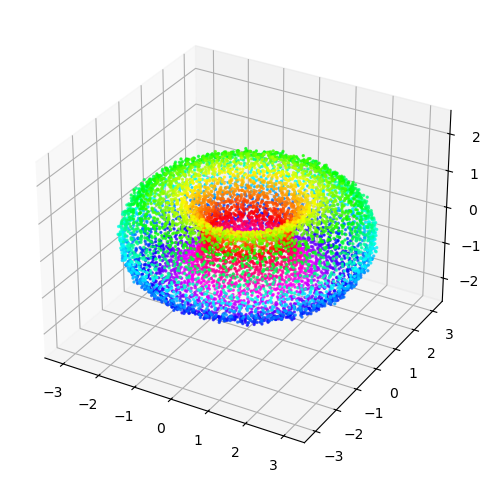

3


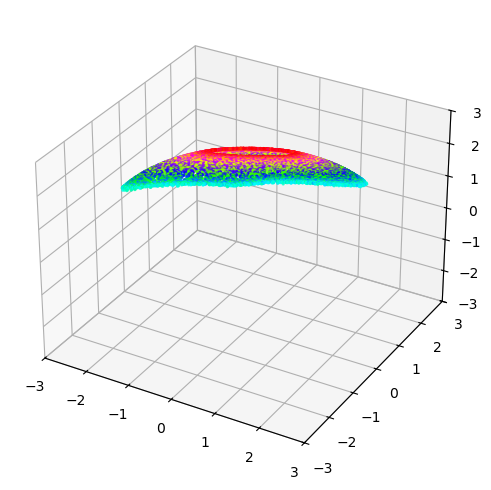

3


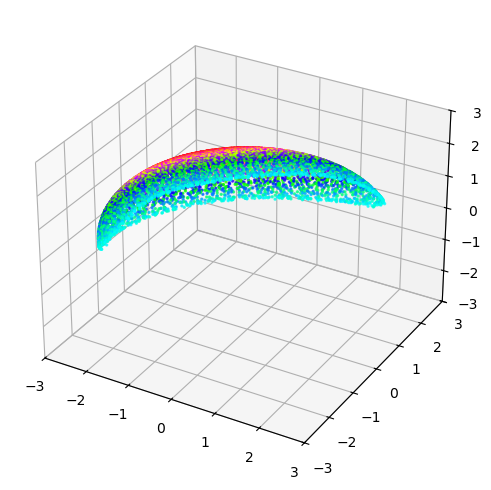

3


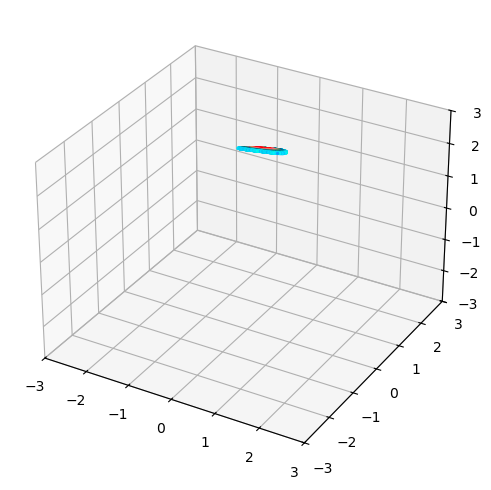

3


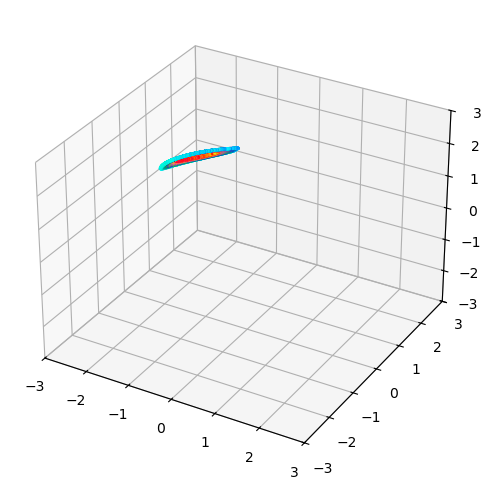

In [23]:
base_path = "../OLD_notebooks_m_ae/learned_vectors/"
file_paths = [
    "vectors_exp00_toroidal_topo_AE_normalized_.pt",
    "vectors_exp01_toroidal_topo_AE_normalized_.pt",
    "vectors_exp02_toroidal_topo_AE_normalized_.pt",
    "vectors_exp03_toroidal_topo_AE_normalized_.pt",
]

# directory where the figures will be saved
save_path = "plots/m_ae"

# run the plotting function
plot_inputs_latents(
    base_path_curv=base_path,
    file_paths=file_paths,
    save_path=save_path,
    dataset_name="t2_synthetic",
    no_axis=False,
    plot_recons=False,
    show_plot=True,  # set False if you only want files saved
    torus_normalized=True,
)

10


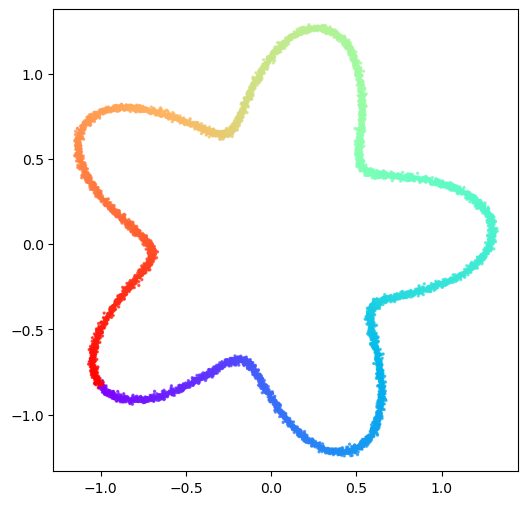

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


2


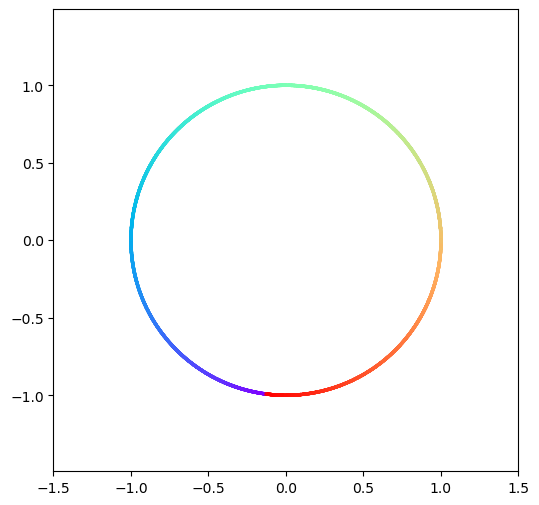

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


2


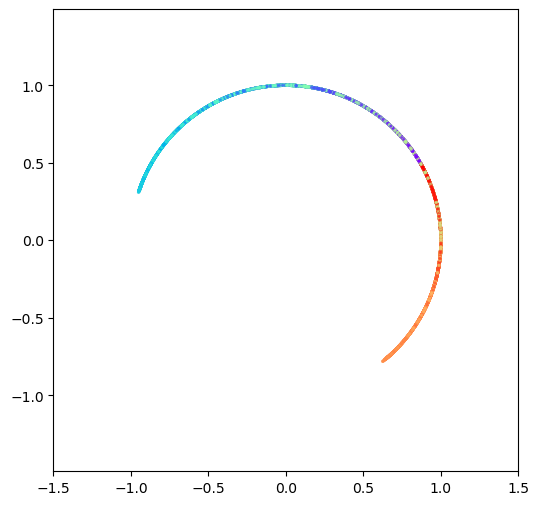

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


2


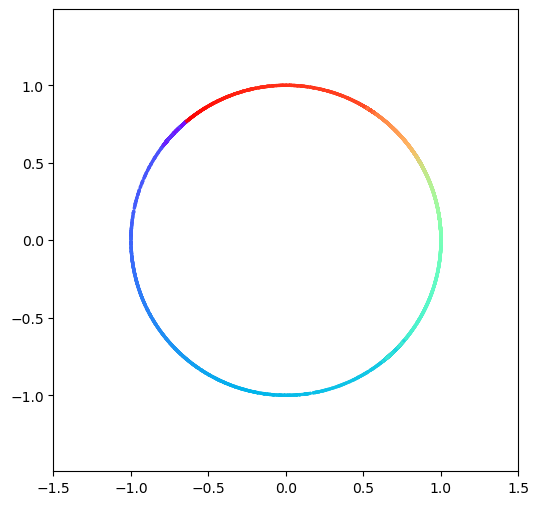

10


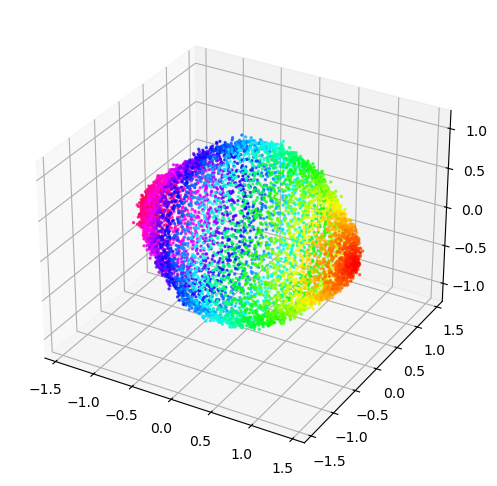

3


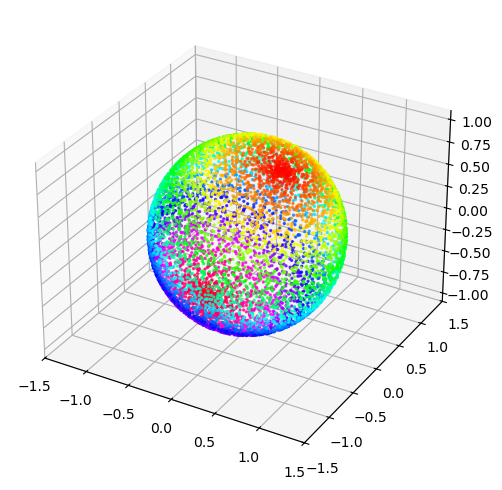

3


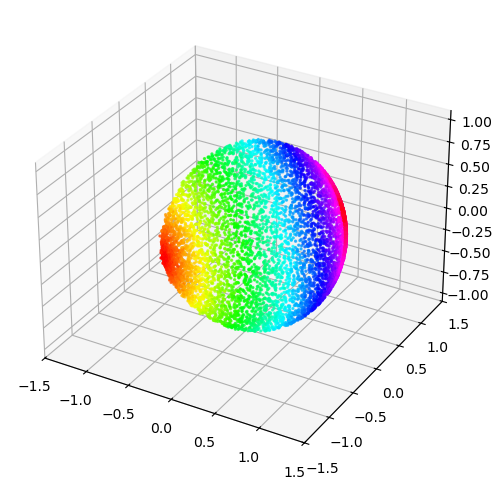

3


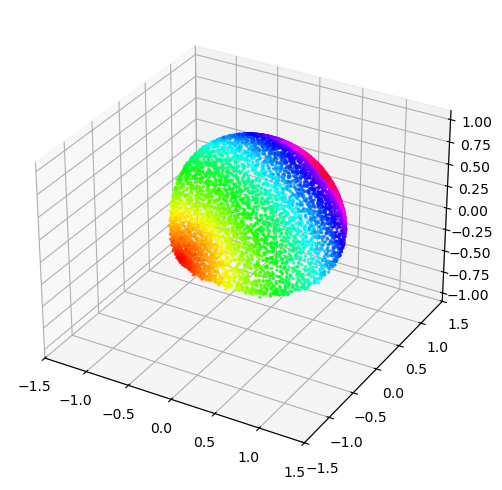

3


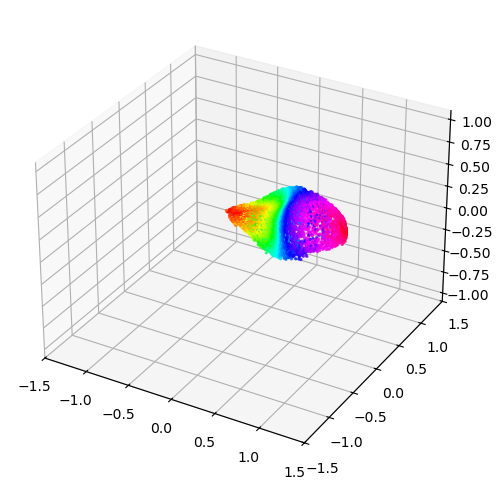

In [31]:
base_path = "../OLD_notebooks_m_ae/learned_vectors/"
# directory where the figures will be saved
save_path = "plots/m_ae"

file_paths = [
    "vectors_exp00_spherical_AE_normalized_.pt",
    "vectors_exp01_spherical_AE_normalized_.pt",
    "vectors_exp02_spherical_AE_normalized_.pt",
]
# run the plotting function
plot_inputs_latents(
    base_path_curv=base_path,
    file_paths=file_paths,
    save_path=save_path,
    dataset_name="s1_synthetic",
    no_axis=False,
    plot_recons=False,
    show_plot=True,  # set False if you only want files saved
    torus_normalized=True,
)

file_paths = [
    "vectors_exp03_spherical_AE_normalized_.pt",
    "vectors_exp04_spherical_AE_normalized_.pt",
    "vectors_exp05_spherical_AE_normalized_.pt",
    "vectors_exp06_spherical_AE_normalized_.pt",
]
# run the plotting function
plot_inputs_latents(
    base_path_curv=base_path,
    file_paths=file_paths,
    save_path=save_path,
    dataset_name="s2_synthetic",
    no_axis=False,
    plot_recons=False,
    show_plot=True,  # set False if you only want files saved
    torus_normalized=False,
)

# Manifold VAEs

In [ ]:
base_path = "../OLD_notebooks_m_vae/learned_vectors/"
file_paths = [
    "vectors_exp01_t_vae_torus_low_.pt",
    "vectors_exp02_t_vae_torus_low_.pt",
    "vectors_exp04_t_vae_torus_low_.pt",
    "vectors_exp05_t_vae_torus_low_.pt",
    "vectors_exp10_t_vae_torus_low_.pt",
    "vectors_exp11_t_vae_torus_low_.pt",
    "vectors_exp16_t_vae_torus_low_.pt",
    "vectors_exp17_t_vae_torus_low_.pt",
]

# directory where the figures will be saved
save_path = "plots/m_vae"

# run the plotting function
plot_inputs_latents(
    base_path_curv=base_path,
    file_paths=file_paths,
    save_path=save_path,
    dataset_name="t2_synthetic",
    no_axis=False,
    plot_recons=False,
    show_plot=True  # set False if you only want files saved
)

In [ ]:
base_path = "../OLD_notebooks_m_vae/learned_vectors/"
file_paths = [
    "vectors_exp01_vmf_torus_high_dim_.pt",
    "vectors_exp02_vmf_vae_torus_high_dim_.pt",
    "vectors_exp04_t_vae_torus_high_dim_.pt",
    "vectors_exp05_t_vae_torus_high_dim_.pt",
    "vectors_exp10_t_vae_torus_high_dim_.pt",
    "vectors_exp11_t_vae_torus_high_dim_.pt",
    "vectors_exp16_t_vae_torus_high_dim_.pt",
    "vectors_exp17_t_vae_torus_high_dim_.pt",
]

# directory where the figures will be saved
save_path = "plots/m_vae"

# run the plotting function
plot_inputs_latents(
    base_path_curv=base_path,
    file_paths=file_paths,
    save_path=save_path,
    dataset_name="torus",
    no_axis=False,
    plot_recons=False,
    show_plot=True  # set False if you only want files saved
)

In [ ]:
base_path = "../OLD_notebooks_m_vae/learned_vectors/"
file_paths = [
    "vectors_exp00_m_vae_circle_high_dim_.pt",
    "vectors_exp02_m_vae_circle_high_dim_.pt",
    "vectors_exp03_m_vae_circle_high_dim_.pt",
    "vectors_exp14_m_vae_circle_high_dim_.pt",
]

# directory where the figures will be saved
save_path = "plots/m_vae"

# run the plotting function
plot_inputs_latents(
    base_path_curv=base_path,
    file_paths=file_paths,
    save_path=save_path,
    dataset_name="s1_synthetic",
    no_axis=False,
    plot_recons=False,
    show_plot=True  # set False if you only want files saved
)

In [ ]:
base_path = "../OLD_notebooks_m_vae/learned_vectors/"
file_paths = [
    "vectors_exp00_m_vae_sphere_low_dim_.pt",
    "vectors_exp02_m_vae_sphere_low_dim_.pt",
    "vectors_exp03_m_vae_sphere_low_dim_.pt",
    "vectors_exp20_m_vae_sphere_low_dim_.pt",
]

# directory where the figures will be saved
save_path = "plots/m_vae"

# run the plotting function
plot_inputs_latents(
    base_path_curv=base_path,
    file_paths=file_paths,
    save_path=save_path,
    dataset_name="s2_synthetic",
    no_axis=False,
    plot_recons=False,
    show_plot=True  # set False if you only want files saved
)

In [ ]:
base_path = "../OLD_notebooks_m_vae/learned_vectors/"
file_paths = [
    "vectors_exp00_m_vae_sphere_high_dim_.pt",
    "vectors_exp02_m_vae_sphere_high_dim_.pt",
    "vectors_exp03_m_vae_sphere_high_dim_.pt",
    "vectors_exp20_m_vae_sphere_high_dim_.pt",
]

# directory where the figures will be saved
save_path = "plots/m_vae"

# run the plotting function
plot_inputs_latents(
    base_path_curv=base_path,
    file_paths=file_paths,
    save_path=save_path,
    dataset_name="sphere",
    no_axis=False,
    plot_recons=False,
    show_plot=True  # set False if you only want files saved
)

# Other

In [ ]:

base_path = '../OLD_notebooks_m_ae/curvatures/'
file_paths = [
    "curvatures_exp00_m_ae_sphere_low_dim.pt",
    "curvatures_exp01_m_ae_sphere_low_dim.pt",
    "curvatures_exp04_m_ae_sphere_low_dim.pt",
    "curvatures_exp07_m_ae_sphere_low_dim.pt"
]

# sort for consistent ordering
file_paths = sorted(file_paths)

# plot_inputs_latents(
#     base_path_curv=base_path,
#     file_paths=file_paths,
#     save_path='plots/m_ae',
#     dataset_name='s2_synthetic',
#     show_plot=False
# )


base_path = '../OLD_notebooks_m_ae/curvatures/'
file_paths = [
    "curvatures_exp00_m_ae_torus_low_dim.pt",
    "curvatures_exp01_m_ae_torus_low_dim.pt",
    "curvatures_exp04_m_ae_torus_low_dim.pt",
    "curvatures_exp07_m_ae_torus_low_dim.pt"
]

# sort for consistent ordering
file_paths = sorted(file_paths)

plot_inputs_latents(
    base_path_curv=base_path,
    file_paths=file_paths,
    save_path='plots/m_ae',
    dataset_name='t2_synthetic',
    show_plot=True
)

In [ ]:
base_path = '../OLD_notebooks_m_vae/curvatures/'
file_paths = []
for f in os.listdir(base_path):
    if f.startswith("curvatures_exp") and f.endswith("_vmf_torus_high_dim.pt"):
        file_paths.append(f)

# sort for consistent ordering
file_paths = sorted(file_paths)

plot_inputs_latents(
    base_path_curv=base_path,
    file_paths=file_paths,
    save_path='plots/',
    dataset_name='torus_high_dim',
    show_plot=True
)

In [ ]:
import os

# base directory containing your torch files
base_path_curv = "../OLD_notebooks_m_vae/learned_vectors/"

# list of torch files you want to visualize
file_paths = [
    "vectors_exp04_t_vae_torus_low_.pt",
]

# directory where the figures will be saved
save_path = "plots/m_vae"

# run the plotting function
plot_inputs_latents(
    base_path_curv=base_path_curv,
    file_paths=file_paths,
    save_path=save_path,
    dataset_name="t2_synthetic",
    show_plot=True  # set False if you only want files saved
)
